In [31]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.linalg import vector_norm


def vectorize(x, multichannel=False):
    """Vectorize data in any shape.

    Args:
        x (torch.Tensor): input data
        multichannel (bool, optional): whether to keep the multiple channels (in the second dimension). Defaults to False.

    Returns:
        torch.Tensor: data of shape (sample_size, dimension) or (sample_size, num_channel, dimension) if multichannel is True.
    """
    if len(x.shape) == 1:
        return x.unsqueeze(1)
    if len(x.shape) == 2:
        return x
    else:
        if not multichannel: # one channel
            return x.reshape(x.shape[0], -1)
        else: # multi-channel
            return x.reshape(x.shape[0], x.shape[1], -1)


class Net(nn.Module):    
    def __init__(self, in_dim, out_dim, hidden_dim, use_bn=False, dropout=0.0):
        super(Net, self).__init__()
        self.use_bn = use_bn
        self.dropout = dropout
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, out_dim)

        if self.use_bn:
            self.bn1 = nn.BatchNorm1d(hidden_dim)
            self.bn2 = nn.BatchNorm1d(hidden_dim)
        if self.dropout > 0.0:
            self.drop = nn.Dropout(dropout)

        self._to()
    
    def _to(self):
        return super(Net, self).to(self.device)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        if self.use_bn:
            x = self.bn1(x)
        if self.dropout > 0.0:
            x = self.drop(x)
        x = F.relu(self.fc2(x))
        if self.use_bn:
            x = self.bn2(x)
        if self.dropout > 0.0:
            x = self.drop(x)
        x = self.fc3(x)
        return x
    


class PreANNet(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim, noise_dim, noise_std=1, use_bn=False, dropout=0.0):
        super(PreANNet, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.hidden_dim = hidden_dim
        self.noise_dim = noise_dim
        self.use_bn = use_bn
        self.dropout = dropout
        self.noise_std = noise_std
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.fc1 = nn.Linear(in_dim + noise_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, out_dim)

        if self.use_bn:
            self.bn1 = nn.BatchNorm1d(hidden_dim)
            self.bn2 = nn.BatchNorm1d(hidden_dim)
        if self.dropout > 0.0:
            self.drop = nn.Dropout(dropout)

        self._to()

    def _to(self):
        return super(PreANNet, self).to(self.device)

    def _draw_noise(self, batch_size):
        return torch.randn(batch_size, self.noise_dim).to(self.device) * self.noise_std 
    
    def sample(self, x, n=100):
        samples = []
        for _ in range(n):
            out = self.forward(x)
            samples.append(out.unsqueeze(0))
        return samples

    def forward(self, x):
        B = x.size(0) # batch size
        noise = self._draw_noise(B)
        x = torch.cat([x, noise], dim=1)
        x = F.relu(self.fc1(x))
        if self.use_bn:
            x = self.bn1(x)
        if self.dropout > 0.0:
            x = self.drop(x)
        x = F.relu(self.fc2(x))
        if self.use_bn:
            x = self.bn2(x)
        if self.dropout > 0.0:
            x = self.drop(x)
        x = self.fc3(x)
        return x



def energy_loss(x_true, x_est, beta=1, verbose=True):
    """Loss function based on the energy score.

    Args:
        x_true (torch.Tensor): iid samples from the true distribution of shape (data_size, data_dim)
        x_est (list of torch.Tensor): 
            - a list of length sample_size, where each element is a tensor of shape (data_size, data_dim) that contains one sample for each data point from the estimated distribution, or 
            - a tensor of shape (data_size*sample_size, response_dim) such that x_est[data_size*(i-1):data_size*i,:] contains one sample for each data point, for i = 1, ..., sample_size.
        beta (float): power parameter in the energy score.
        verbose (bool): whether to return two terms of the loss.

    Returns:
        loss (torch.Tensor): energy loss.
    """
    EPS = 0 if float(beta).is_integer() else 1e-5
    x_true = vectorize(x_true).unsqueeze(1)
    if not isinstance(x_est, list):
        x_est = list(torch.split(x_est, x_true.shape[0], dim=0))
    m = len(x_est)
    x_est = [vectorize(x_est[i]).unsqueeze(1) for i in range(m)]
    x_est = torch.cat(x_est, dim=1)
        
    s1 = (vector_norm(x_est - x_true, 2, dim=2) + EPS).pow(beta).mean()
    s2 = (torch.cdist(x_est, x_est, 2) + EPS).pow(beta).mean() * m / (m - 1)
    if verbose:
        return torch.cat([(s1 - s2 / 2).reshape(1), s1.reshape(1), s2.reshape(1)], dim=0)
    else:
        return (s1 - s2 / 2)
    

engnet = PreANNet(in_dim=10, out_dim=1, hidden_dim=64, noise_dim=5, noise_std=0.1, use_bn=True, dropout=0.2)
x = torch.randn(3, 10).to(engnet.device)
y = engnet.forward(x)

y_samples = engnet.sample(x)

Epoch 10/200, Loss: 5.6615
Epoch 20/200, Loss: 5.7370
Epoch 30/200, Loss: 5.7551
Epoch 40/200, Loss: 4.7968
Epoch 50/200, Loss: 3.5643
Epoch 60/200, Loss: 2.7859
Epoch 70/200, Loss: 2.5623
Epoch 80/200, Loss: 2.0960
Epoch 90/200, Loss: 2.3709
Epoch 100/200, Loss: 2.4231
Epoch 110/200, Loss: 2.4851
Epoch 120/200, Loss: 2.4087
Epoch 130/200, Loss: 2.4314
Epoch 140/200, Loss: 2.2839
Epoch 150/200, Loss: 1.8582
Epoch 160/200, Loss: 2.3837
Epoch 170/200, Loss: 2.2638
Epoch 180/200, Loss: 1.8248
Epoch 190/200, Loss: 1.9231
Epoch 200/200, Loss: 2.2230


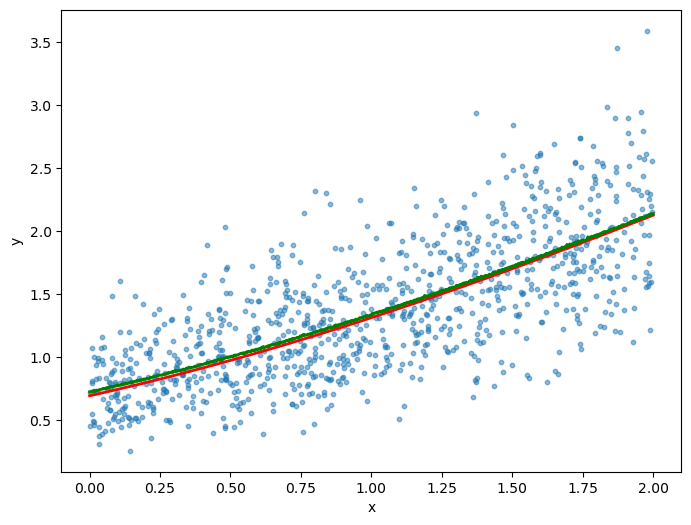

In [35]:
import numpy as np

def preanm_simulator(true_function="softplus", n=10000, x_lower=0, x_upper=2, noise_std=1, noise_dist="gaussian", train=True, device=torch.device("cpu")):
    """Data simulator for a pre-additive noise model (pre-ANM).

    Args:
        true_function (str, optional): true function g^\star. Defaults to "softplus". Choices: ["softplus", "cubic","square", "log"].
        n (int, optional): sample size. Defaults to 10000.
        x_lower (int, optional): lower bound of the training support. Defaults to 0.
        x_upper (int, optional): upper bound of the training support. Defaults to 2.
        noise_std (int, optional): standard deviation of the noise. Defaults to 1.
        noise_dist (str, optional): noise distribution. Defaults to "gaussian". Choices: ["gaussian", "uniform"].
        train (bool, optional): generate data for training. Defaults to True.
        device (str or torch.device, optional): device. Defaults to torch.device("cpu").

    Returns:
        tuple of torch.Tensors: data simulated from a pre-ANM.
    """
    if isinstance(true_function, str):
        if true_function == "softplus":
            true_function = lambda x: nn.Softplus()(x)
        elif true_function == "cubic":
            true_function = lambda x: x.pow(3)/3
        elif true_function == "square":
            true_function = lambda x: (nn.functional.relu(x)).pow(2)/2
        elif true_function == "log":
            true_function = lambda x: (x/3 + np.log(3) - 2/3)*(x <= 2) + (torch.log(1 + x*(x > 2)))*(x > 2) 
            
    if isinstance(device, str):
            device = torch.device(device)
            
    if train:
        x = torch.rand(n, 1)*(x_upper - x_lower) + x_lower
        if noise_dist == "gaussian":
            eps = torch.randn(n, 1)*noise_std
        else:
            assert noise_dist == "uniform"
            eps = (torch.rand(n, 1) - 0.5)*noise_std*np.sqrt(12)
        xn = x + eps
        y = true_function(xn)
        return x.to(device), y.to(device)
    
    else:
        x_eval = torch.linspace(x_lower, x_upper, n).unsqueeze(1)
        y_eval_med = true_function(x_eval)
        gen_sample_size = 10000
        x_rep = torch.repeat_interleave(x_eval, (gen_sample_size * torch.ones(n)).long(), dim=0)
        x_rep = x_rep + torch.randn(x_rep.size(0), 1)*noise_std
        y_eval_mean = true_function(x_rep)
        y_eval_mean = list(torch.split(y_eval_mean, gen_sample_size))
        y_eval_mean = torch.cat([y_eval_mean[i].mean().unsqueeze(0) for i in range(n)], dim=0).unsqueeze(1)
        return x_eval.to(device), y_eval_med.to(device), y_eval_mean.to(device)
    

# generate training data
x_train, y_train = preanm_simulator(true_function="softplus", n=1000, x_lower=0, x_upper=2, noise_std=0.5, noise_dist="gaussian", train=True, device=torch.device("cpu"))
x_eval, y_eval_med, y_eval_mean = preanm_simulator(true_function="softplus", n=1000, x_lower=0, x_upper=2, noise_std=0.5, noise_dist="gaussian", train=False, device=torch.device("cpu"))

# visualize training data and true function
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(x_train.cpu(), y_train.cpu(), s=10, alpha=0.5, label="Training data")
plt.plot(x_eval.cpu(), y_eval_med.cpu(), color='red', linewidth=2, label="True function (median)")
plt.plot(x_eval.cpu(), y_eval_mean.cpu(), color='green', linewidth=2, label="True function (mean)")
plt.xlabel("x")
plt.ylabel("y")

# train PreANNet
prean_net = PreANNet(in_dim=1, out_dim=1, hidden_dim=64, noise_dim=5, noise_std=1, use_bn=True, dropout=0.2)
prean_net
optimizer = torch.optim.Adam(prean_net.parameters(), lr=0.0001)
num_epochs = 200
batch_size = 64
for epoch in range(num_epochs):
    perm = torch.randperm(x_train.size(0))
    x_train = x_train[perm]
    y_train = y_train[perm]
    for i in range(0, x_train.size(0), batch_size):
        x_batch = x_train[i:i+batch_size].to(prean_net.device)
        y_batch = y_train[i:i+batch_size].to(prean_net.device)
        y_pred_samples = prean_net.sample(x_batch.to(prean_net.device), n=10)
        loss = energy_loss(y_batch, y_pred_samples, beta=1, verbose=False)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

Visualization of learned function:


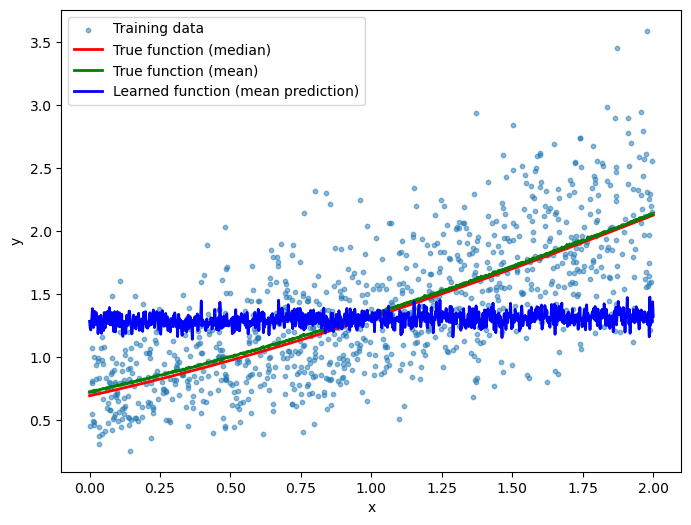

In [38]:
# visualize learned function
y_pred_samples = prean_net.sample(x_eval.to(prean_net.device), n=100)
y_pred_mean = torch.cat([y_pred_samples[i] for i in range(len(y_pred_samples))], dim=0)

print("Visualization of learned function:")
plt.figure(figsize=(8,6))
plt.scatter(x_train.cpu(), y_train.cpu(), s=10, alpha=0.5, label="Training data")
plt.plot(x_eval.cpu(), y_eval_med.cpu(), color='red', linewidth=2, label="True function (median)")
plt.plot(x_eval.cpu(), y_eval_mean.cpu(), color='green', linewidth=2, label="True function (mean)")
plt.plot(x_eval.cpu(), y_pred_mean.mean(dim=0).detach().cpu(), color='blue', linewidth=2, label="Learned function (mean prediction)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

Using device: cuda


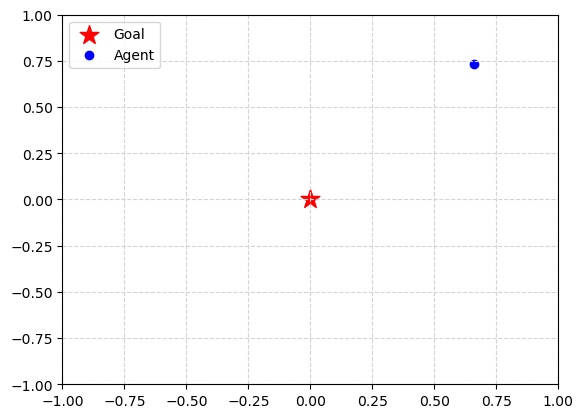

[0.6587859  0.73563445]
[ 1.         -0.36436555] 1


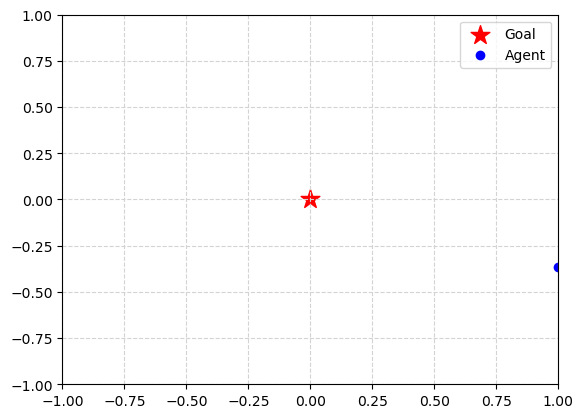

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from collections import deque
import time
import matplotlib.pyplot as plt

# --- Hyperparameters ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Environment
STATE_DIM = 2
ACTION_DIM = 2
MAX_ACTION = 0.2
GOAL_POS = np.array([0.0, 0.0])
ENV_BOUNDS = [-1.0, 1.0]
MAX_STEPS = 100

# Training
MAX_EPISODES = 2000
REPLAY_BUFFER_SIZE = 100000
BATCH_SIZE = 128
GAMMA = 0.99
TAU = 0.005 # For soft target update
EXPLORATION_NOISE = 0.1 # Standard exploration noise
POLICY_FREQ = 2 # Delayed policy update for DDPG
LR_ACTOR = 1e-3
LR_CRITIC = 1e-3

# Agent-Specific
PRE_ADDITIVE_NOISE_STD = 0.1 # The "Engression" noise std
NUM_QUANTILES = 51 # For QR-DDPG (Agent 2)

# Evaluation
EVAL_FREQ = 200 # Evaluate every N episodes
EVAL_EPISODES = 10


# ---------------------------------
# 1. ENVIRONMENT SETUP
# ---------------------------------

class Constrained2DEnv:
    """A simple 2D navigation environment with a constrained training domain."""
    
    def __init__(self):
        self.state_dim = STATE_DIM
        self.action_dim = ACTION_DIM
        self.max_action = MAX_ACTION
        self.goal = GOAL_POS
        self.bounds = ENV_BOUNDS
        self.step_count = 0

    def reset(self, mode='train'):
        """
        Resets the environment.
        'train':       Top-right quadrant (Interpolation)
        'test_extrap': Bottom-left quadrant (Extrapolation)
        'test_interp': Top-right quadrant (Sanity check)
        """
        self.step_count = 0
        if mode == 'train' or mode == 'test_interp':
            # Training / Interpolation Domain: Top-Right
            self.state = np.random.uniform(low=0.5, high=1.0, size=STATE_DIM).astype(np.float32)
        elif mode == 'test_extrap':
            # Extrapolation Domain: Bottom-Left
            self.state = np.random.uniform(low=-1.0, high=-0.5, size=STATE_DIM).astype(np.float32)
        else:
            raise ValueError("Invalid reset mode")
        return self.state

    def step(self, action):
        self.step_count += 1
        
        # Clip action
        action = np.clip(action, -self.max_action, self.max_action)
        
        # Dynamics: s_t+1 = s_t + a_t
        next_state = self.state + action
        next_state = np.clip(next_state, self.bounds[0], self.bounds[1]).astype(np.float32)
        
        # Reward: Negative L2 distance to goal
        reward = -np.linalg.norm(next_state - self.goal).astype(np.float32)
        
        # Done condition
        done = (np.linalg.norm(next_state - self.goal) < 0.05) or (self.step_count >= MAX_STEPS)
        
        self.state = next_state
        return next_state, reward, done
    

    def render(self):
        plt.xlim(self.bounds[0], self.bounds[1])
        plt.ylim(self.bounds[0], self.bounds[1])
        plt.scatter(self.goal[0], self.goal[1], c='red', marker='*', s=200, label='Goal')
        plt.scatter(self.state[0], self.state[1], c='blue', label='Agent')
        plt.legend()
        plt.grid(color='lightgray', linestyle='--')
        plt.show()


env = Constrained2DEnv()
state = env.reset(mode='train')
env.render()
print(env.state)
next_state, reward, done = env.step(np.array([1.5, -1.1]))
print(env.state, env.step_count)
env.render()

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from collections import deque
import time

# --- Hyperparameters ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Environment
STATE_DIM = 2
ACTION_DIM = 2
MAX_ACTION = 0.1
GOAL_POS = np.array([0.0, 0.0])
ENV_BOUNDS = [-1.0, 1.0]
MAX_STEPS = 100

# Training
MAX_EPISODES = 2000
REPLAY_BUFFER_SIZE = 100000
BATCH_SIZE = 128
GAMMA = 0.99
TAU = 0.005 # For soft target update
EXPLORATION_NOISE = 0.1 # Standard exploration noise
POLICY_FREQ = 2 # Delayed policy update for DDPG
LR_ACTOR = 1e-3
LR_CRITIC = 1e-3

# Agent-Specific
PRE_ADDITIVE_NOISE_STD = 0.1 # The "Engression" noise std
NUM_QUANTILES = 51 # For QR-DDPG (Agent 2)

# Evaluation
EVAL_FREQ = 200 # Evaluate every N episodes
EVAL_EPISODES = 10


# ---------------------------------
# 1. ENVIRONMENT SETUP
# ---------------------------------

class Constrained2DEnv:
    """A simple 2D navigation environment with a constrained training domain."""
    
    def __init__(self):
        self.state_dim = STATE_DIM
        self.action_dim = ACTION_DIM
        self.max_action = MAX_ACTION
        self.goal = GOAL_POS
        self.bounds = ENV_BOUNDS
        self.step_count = 0

    def reset(self, mode='train'):
        """
        Resets the environment.
        'train':       Top-right quadrant (Interpolation)
        'test_extrap': Bottom-left quadrant (Extrapolation)
        'test_interp': Top-right quadrant (Sanity check)
        """
        self.step_count = 0
        if mode == 'train' or mode == 'test_interp':
            # Training / Interpolation Domain: Top-Right
            self.state = np.random.uniform(low=0.5, high=1.0, size=STATE_DIM).astype(np.float32)
        elif mode == 'test_extrap':
            # Extrapolation Domain: Bottom-Left
            self.state = np.random.uniform(low=-1.0, high=-0.5, size=STATE_DIM).astype(np.float32)
        else:
            raise ValueError("Invalid reset mode")
        return self.state

    def step(self, action):
        self.step_count += 1
        
        # Clip action
        action = np.clip(action, -self.max_action, self.max_action)
        
        # Dynamics: s_t+1 = s_t + a_t
        next_state = self.state + action
        next_state = np.clip(next_state, self.bounds[0], self.bounds[1]).astype(np.float32)
        
        # Reward: Negative L2 distance to goal
        reward = -np.linalg.norm(next_state - self.goal).astype(np.float32)
        
        # Done condition
        done = (np.linalg.norm(next_state - self.goal) < 0.05) or (self.step_count >= MAX_STEPS)
        
        self.state = next_state
        return next_state, reward, done

# ---------------------------------
# 2. COMMON COMPONENTS
# ---------------------------------

class ReplayBuffer:
    def __init__(self, capacity=REPLAY_BUFFER_SIZE):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size))
        
        return (
            torch.tensor(np.array(state), dtype=torch.float32).to(DEVICE),
            torch.tensor(np.array(action), dtype=torch.float32).to(DEVICE),
            torch.tensor(np.array(reward), dtype=torch.float32).unsqueeze(1).to(DEVICE),
            torch.tensor(np.array(next_state), dtype=torch.float32).to(DEVICE),
            torch.tensor(np.array(done), dtype=torch.float32).unsqueeze(1).to(DEVICE)
        )

    def __len__(self):
        return len(self.buffer)

class Actor(nn.Module):
    """Standard DDPG Actor Network"""
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.l1 = nn.Linear(state_dim, 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, action_dim)
        self.max_action = max_action

    def forward(self, state):
        a = F.relu(self.l1(state))
        a = F.relu(self.l2(a))
        a = torch.tanh(self.l3(a)) * self.max_action
        return a

class Critic_MSE(nn.Module):
    """Standard DDPG Critic Network (outputs 1 Q-value)"""
    def __init__(self, state_dim, action_dim):
        super(Critic_MSE, self).__init__()
        self.l1 = nn.Linear(state_dim + action_dim, 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, 1)

    def forward(self, state, action):
        sa = torch.cat([state, action], 1)
        q = F.relu(self.l1(sa))
        q = F.relu(self.l2(q))
        q = self.l3(q)
        return q

class Critic_QR(nn.Module):
    """Quantile Regression Critic Network (outputs N quantiles)"""
    def __init__(self, state_dim, action_dim, num_quantiles):
        super(Critic_QR, self).__init__()
        self.num_quantiles = num_quantiles
        self.l1 = nn.Linear(state_dim + action_dim, 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, num_quantiles)

    def forward(self, state, action):
        sa = torch.cat([state, action], 1)
        q = F.relu(self.l1(sa))
        q = F.relu(self.l2(q))
        q_quantiles = self.l3(q)
        return q_quantiles

# ---------------------------------
# 3. AGENT DEFINITIONS
# ---------------------------------

class BaseAgent:
    """Base class to hold shared logic"""
    def __init__(self):
        self.total_it = 0
        self.replay_buffer = ReplayBuffer()

    def select_action(self, state):
        # This is for evaluation (inference)
        state = torch.tensor(state.reshape(1, -1), dtype=torch.float32).to(DEVICE)
        return self.actor(state).cpu().data.numpy().flatten()

    def soft_update_target_networks(self):
        # Soft update of the target networks
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)
        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)
    
    def add_exploration_noise(self, action):
        noise = np.random.normal(0, MAX_ACTION * EXPLORATION_NOISE, size=ACTION_DIM)
        return (action + noise).clip(-MAX_ACTION, MAX_ACTION)

    def train(self, state, action, reward, next_state, done):
        self.total_it += 1
        self.replay_buffer.push(state, action, reward, next_state, done)
        
        if len(self.replay_buffer) < BATCH_SIZE:
            return

        self.update()


class Agent1_Baseline_DDPG(BaseAgent):
    """AGENT 1: Simple MLP (Standard DDPG)
    - Critic Loss: MSE
    - Input Noise: No
    """
    def __init__(self):
        super().__init__()
        self.name = "Baseline_DDPG (MSE)"
        
        self.actor = Actor(STATE_DIM, ACTION_DIM, MAX_ACTION).to(DEVICE)
        self.actor_target = Actor(STATE_DIM, ACTION_DIM, MAX_ACTION).to(DEVICE)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=LR_ACTOR)

        self.critic = Critic_MSE(STATE_DIM, ACTION_DIM).to(DEVICE)
        self.critic_target = Critic_MSE(STATE_DIM, ACTION_DIM).to(DEVICE)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=LR_CRITIC)
        
    def update(self):
        state, action, reward, next_state, done = self.replay_buffer.sample(BATCH_SIZE)

        # --- Critic Update (MSE Loss) ---
        with torch.no_grad():
            next_action = self.actor_target(next_state)
            target_q = self.critic_target(next_state, next_action)
            target_q = reward + (1 - done) * GAMMA * target_q
        
        current_q = self.critic(state, action)
        
        critic_loss = F.mse_loss(current_q, target_q)
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # --- Delayed Actor Update ---
        if self.total_it % POLICY_FREQ == 0:
            actor_loss = -self.critic(state, self.actor(state)).mean()
            
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()

            self.soft_update_target_networks()


class Agent2_Engression_QR_DDPG(BaseAgent):
    """AGENT 2: Engression-Type (QR-DDPG + Noise)
    - Critic Loss: Quantile Regression (Pinball) Loss
    - Input Noise: Yes
    """
    def __init__(self):
        super().__init__()
        self.name = "Engression_QR_DDPG (Distr + Noise)"
        self.noise_std = PRE_ADDITIVE_NOISE_STD
        self.num_quantiles = NUM_QUANTILES
        
        # Pre-compute quantile fractions
        # (0.01, 0.03, ..., 0.99)
        taus = torch.arange(0.5 / self.num_quantiles, 1.0, 1.0 / self.num_quantiles).to(DEVICE)
        self.quantile_taus = taus.view(1, 1, self.num_quantiles) # Shape (1, 1, N) for broadcasting

        self.actor = Actor(STATE_DIM, ACTION_DIM, MAX_ACTION).to(DEVICE)
        self.actor_target = Actor(STATE_DIM, ACTION_DIM, MAX_ACTION).to(DEVICE)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=LR_ACTOR)

        self.critic = Critic_QR(STATE_DIM, ACTION_DIM, self.num_quantiles).to(DEVICE)
        self.critic_target = Critic_QR(STATE_DIM, ACTION_DIM, self.num_quantiles).to(DEVICE)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=LR_CRITIC)
    
    def update(self):
        state, action, reward, next_state, done = self.replay_buffer.sample(BATCH_SIZE)

        # --- ADD PRE-ADDITIVE NOISE ---
        noise_s = torch.randn_like(state) * self.noise_std
        noise_a = torch.randn_like(action) * self.noise_std
        noise_s_next = torch.randn_like(next_state) * self.noise_std
        
        noisy_state = (state + noise_s).clamp(ENV_BOUNDS[0], ENV_BOUNDS[1])
        noisy_action = (action + noise_a).clamp(-MAX_ACTION, MAX_ACTION)
        noisy_next_state = (next_state + noise_s_next).clamp(ENV_BOUNDS[0], ENV_BOUNDS[1])
        
        # --- Critic Update (Quantile Loss) ---
        with torch.no_grad():
            next_action = self.actor_target(noisy_next_state)
            target_q_quantiles = self.critic_target(noisy_next_state, next_action) # (B, N)
            
            # Target quantiles: y_i = r + gamma * Z'_i
            target_q_quantiles = reward + (1 - done) * GAMMA * target_q_quantiles
            # Reshape for broadcasting: (B, N) -> (B, N, 1)
            target_q_quantiles = target_q_quantiles.unsqueeze(-1) 
        
        current_q_quantiles = self.critic(noisy_state, noisy_action) # (B, N)
        # Reshape for broadcasting: (B, N) -> (B, 1, N)
        current_q_quantiles = current_q_quantiles.unsqueeze(-2)
        
        # Calculate Quantile (Pinball) Loss
        # u_ij = y_i - Z_j
        td_errors = target_q_quantiles - current_q_quantiles # Shape (B, N, N)
        
        # Pinball loss: L = |tau - (u < 0)| * |u|
        # We use F.smooth_l1_loss (Huber loss) for stability, which is common
        # The key is the asymmetry from self.quantile_taus
        pinball_loss = torch.abs(self.quantile_taus - (td_errors < 0).float()) * F.huber_loss(td_errors, torch.zeros_like(td_errors), reduction='none')
        
        # We sum over target quantiles (dim 1) and mean over batch and current quantiles (dims 0, 2)
        critic_loss = pinball_loss.sum(dim=1).mean()

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # --- Delayed Actor Update ---
        if self.total_it % POLICY_FREQ == 0:
            # Actor maximizes the MEAN of the quantile distribution
            actor_quantiles = self.critic(noisy_state, self.actor(noisy_state))
            actor_loss = -actor_quantiles.mean()
            
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()

            self.soft_update_target_networks()


class Agent3_Noise_MSE_DDPG(BaseAgent):
    """AGENT 3: Naive Model (MSE + Noise)
    - Critic Loss: MSE
    - Input Noise: Yes
    """
    def __init__(self):
        super().__init__()
        self.name = "Noise_MSE_DDPG (MSE + Noise)"
        self.noise_std = PRE_ADDITIVE_NOISE_STD
        
        self.actor = Actor(STATE_DIM, ACTION_DIM, MAX_ACTION).to(DEVICE)
        self.actor_target = Actor(STATE_DIM, ACTION_DIM, MAX_ACTION).to(DEVICE)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=LR_ACTOR)

        self.critic = Critic_MSE(STATE_DIM, ACTION_DIM).to(DEVICE)
        self.critic_target = Critic_MSE(STATE_DIM, ACTION_DIM).to(DEVICE)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=LR_CRITIC)
        
    def update(self):
        state, action, reward, next_state, done = self.replay_buffer.sample(BATCH_SIZE)

        # --- ADD PRE-ADDITIVE NOISE ---
        noise_s = torch.randn_like(state) * self.noise_std
        noise_a = torch.randn_like(action) * self.noise_std
        noise_s_next = torch.randn_like(next_state) * self.noise_std
        
        noisy_state = (state + noise_s).clamp(ENV_BOUNDS[0], ENV_BOUNDS[1])
        noisy_action = (action + noise_a).clamp(-MAX_ACTION, MAX_ACTION)
        noisy_next_state = (next_state + noise_s_next).clamp(ENV_BOUNDS[0], ENV_BOUNDS[1])

        # --- Critic Update (MSE Loss) ---
        with torch.no_grad():
            # Target calculation uses noisy next state
            next_action = self.actor_target(noisy_next_state)
            target_q = self.critic_target(noisy_next_state, next_action)
            target_q = reward + (1 - done) * GAMMA * target_q
        
        # Current Q calculation uses noisy current state/action
        current_q = self.critic(noisy_state, noisy_action)
        
        critic_loss = F.mse_loss(current_q, target_q)
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # --- Delayed Actor Update ---
        if self.total_it % POLICY_FREQ == 0:
            # Actor loss calculation uses noisy state
            actor_loss = -self.critic(noisy_state, self.actor(noisy_state)).mean()
            
            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()

            self.soft_update_target_networks()

# ---------------------------------
# 4. BENCHMARKING SCRIPT
# ---------------------------------

def evaluate_agent(agent, env, num_episodes):
    """Evaluates the agent in both interpolation and extrapolation modes."""
    
    # Test 1: Interpolation (Sanity check)
    interp_rewards = []
    for _ in range(num_episodes):
        state = env.reset(mode='test_interp')
        ep_reward = 0
        for t in range(MAX_STEPS):
            action = agent.select_action(state) # No exploration noise
            next_state, reward, done = env.step(action)
            ep_reward += reward
            state = next_state
            if done:
                break
        interp_rewards.append(ep_reward)

    # Test 2: Extrapolation (The real test)
    extrap_rewards = []
    for _ in range(num_episodes):
        state = env.reset(mode='test_extrap')
        ep_reward = 0
        for t in range(MAX_STEPS):
            action = agent.select_action(state) # No exploration noise
            next_state, reward, done = env.step(action)
            ep_reward += reward
            state = next_state
            if done:
                break
        extrap_rewards.append(ep_reward)
        
    return np.mean(interp_rewards), np.mean(extrap_rewards)

def main():
    print("--- Starting Extrapolation Benchmark ---")
    
    env = Constrained2DEnv()
    
    agents = [
        Agent1_Baseline_DDPG(),
        Agent2_Engression_QR_DDPG(),
        Agent3_Noise_MSE_DDPG(),
    ]
    
    results = {agent.name: [] for agent in agents}

    start_time = time.time()
    
    for ep in range(1, MAX_EPISODES + 1):
        state = env.reset(mode='train')
        ep_reward = 0
        
        for t in range(MAX_STEPS):
            # Select action with exploration noise
            # We use the same exploration for all agents for fairness
            action = agents[0].select_action(state)
            action = agents[0].add_exploration_noise(action)
            
            next_state, reward, done = env.step(action)
            ep_reward += reward
            
            # Train all agents on the same experience
            for agent in agents:
                agent.train(state, action, reward, next_state, done)
                
            state = next_state
            if done:
                break
        
        # --- Evaluation Phase ---
        if ep % EVAL_FREQ == 0:
            print(f"\n--- Episode {ep} | Time: {time.time() - start_time:.1f}s ---")
            for agent in agents:
                interp_r, extrap_r = evaluate_agent(agent, env, EVAL_EPISODES)
                results[agent.name].append((interp_r, extrap_r))
                print(f"  {agent.name}:")
                print(f"    - Interpolation Reward: {interp_r:.2f}")
                print(f"    - Extrapolation Reward: {extrap_r:.2f}")

    print("\n--- Final Benchmark Results (Avg Reward) ---")
    for agent in agents:
        final_interp, final_extrap = evaluate_agent(agent, env, num_episodes=50)
        print(f"AGENT: {agent.name}")
        print(f"  - Final Interpolation (Train Domain): {final_interp:.2f}")
        print(f"  - Final Extrapolation (Test Domain):  {final_extrap:.2f}")
        print("-" * 20)

if __name__ == "__main__":
    main()


Using device: cuda
--- Starting Extrapolation Benchmark ---

--- Episode 200 | Time: 69.3s ---
  Baseline_DDPG (MSE):
    - Interpolation Reward: -4.41
    - Extrapolation Reward: -5.48
  Engression_QR_DDPG (Distr + Noise):
    - Interpolation Reward: -62.21
    - Extrapolation Reward: -108.72
  Noise_MSE_DDPG (MSE + Noise):
    - Interpolation Reward: -8.89
    - Extrapolation Reward: -7.66

--- Episode 400 | Time: 86.2s ---
  Baseline_DDPG (MSE):
    - Interpolation Reward: -4.19
    - Extrapolation Reward: -4.05
  Engression_QR_DDPG (Distr + Noise):
    - Interpolation Reward: -89.24
    - Extrapolation Reward: -106.81
  Noise_MSE_DDPG (MSE + Noise):
    - Interpolation Reward: -11.88
    - Extrapolation Reward: -11.67

--- Episode 600 | Time: 103.8s ---
  Baseline_DDPG (MSE):
    - Interpolation Reward: -4.05
    - Extrapolation Reward: -4.92
  Engression_QR_DDPG (Distr + Noise):
    - Interpolation Reward: -92.53
    - Extrapolation Reward: -110.49
  Noise_MSE_DDPG (MSE + Noise):
